## Setup & Data Preprocessing

All three models share the same data pipeline. Complete this section once; it will be reused in every subsequent part.


### Loads the IMDb Dataset

Uses the HuggingFace datasets library to load IMDb. The dataset has 25 000 training reviews and 25 000 test reviews, each labeled 0 (negative) or 1 (positive).


In [1]:
from datasets import load_dataset

dataset = load_dataset("imdb")
train_data = dataset["train"]
test_data  = dataset["test"]

# Quick look
print(train_data[0]["text"][:200])
print("Label:", train_data[0]["label"])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Label: 0


### Tokenisation & Vocabulary

Converts raw text into integer token sequences. We keep the vocabulary to the 20 000 most common words and cap each review at 500 tokens.

In [2]:
import re
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import random
import numpy as np
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F


# ── helpers ──────────────────────────────────────────────
# Setting manual seed for reproducability
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-z']+\b", text)

# Build vocab from training set
VOCAB_SIZE = 20_000
MAX_LEN    = 500
PAD_IDX    = 0
UNK_IDX    = 1

counter = Counter()
for ex in train_data:
    counter.update(tokenize(ex["text"]))

vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
vocab.update({w: i+2 for i, (w, _) in
              enumerate(counter.most_common(VOCAB_SIZE))})

def encode(text):
    tokens = tokenize(text)[:MAX_LEN]
    return [vocab.get(t, UNK_IDX) for t in tokens]

# ── Dataset class ─────────────────────────────────────────
class IMDbDataset(Dataset):
    def __init__(self, split):
        self.samples = [
            (
                torch.tensor(encode(ex["text"]), dtype=torch.long),
                torch.tensor(ex["label"],        dtype=torch.long)
            )
            for ex in dataset[split]
        ]

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def collate(batch):
    texts, labels = zip(*batch)
    # Capture true lengths BEFORE padding
    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)
    texts = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts, torch.stack(labels), lengths  # Return lengths


train_loader = DataLoader(IMDbDataset("train"), batch_size=64,
                          shuffle=True,  collate_fn=collate)
test_loader  = DataLoader(IMDbDataset("test"),  batch_size=64,
                          shuffle=False, collate_fn=collate)

## Vanilla RNN Implementation

A vanilla RNN processes text one token at a time, left to right, maintaining a hidden state that acts as its "memory". Implement the model below and complete the training loop.

The model architecture has three stages: Embed → Recur → Classify.

In [3]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, dropout=0.5):
        super().__init__()

        # padding_idx=0 to ignore and prevent learning weights from padding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, n_classes)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.rnn(embedded)
        batch_size = x.size(0) # Finds total reviews
        out = output[torch.arange(batch_size), lengths - 1] # Extracts hidden state before padding starts
        return self.fc(self.dropout(out)) # Apply dropout to prevent linear classifier from overfitting

# ── Shared training utilities ─────────────────────────────────
def train_model(model, loader, optimizer, criterion, device):
    model.train() # Switch to training mode
    total_loss = 0.0
    correct = 0
    total = 0

    for texts, labels, lengths in loader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Reset Gradients to 0

        predictions = model(texts, lengths) # Forward pass for predictions
        loss = criterion(predictions, labels) # Calculates error
        loss.backward() # Backward pass for gradient calculation

        # Clipping gradients to 1.0 to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() # Update weights

        total_loss += loss.item()
        _, predicted = torch.max(predictions, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate_model(model, loader, criterion, device):
    model.eval() # Switch to evaluation mode
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for texts, labels, lengths in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            predictions = model(texts, lengths) # Forward pass for predictions
            loss = criterion(predictions, labels) # Calculates error

            total_loss += loss.item()
            _, predicted = torch.max(predictions, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def run_training(model, train_loader, test_loader, device, n_epochs=5, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": [],
        "epoch_times": []
    }

    for epoch in range(n_epochs):
        start_time = time.time()

        train_loss, train_acc = train_model(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

        end_time = time.time()
        epoch_time = end_time - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["epoch_times"].append(epoch_time)

        print(f"Epoch {epoch+1}/{n_epochs} | Time: {epoch_time:.2f} seconds")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}%")
        print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc * 100:.2f}%")
        print()

    avg_time = sum(history["epoch_times"]) / n_epochs
    print(f"Average Epoch Time: {avg_time:.2f} seconds")

    return history


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Initiate and Train
set_seed(42)
model_rnn = RNNClassifier(
    vocab_size = len(vocab),
    embed_dim  = 128,
    hidden_dim = 256,
    n_classes  = 2
)
print(model_rnn)

RNNClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (rnn): RNN(128, 256, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


### Running Vanila RNN Model And Plotting Training and Test loss Graph

Vanilla RNN Parameters: 2,659,586
Running Vanilla RNN Model...

Epoch 1/5 | Time: 5.53 seconds
Train Loss: 0.7019 | Train Acc: 53.70%
Test Loss:  0.6893 | Test Acc:  53.61%

Epoch 2/5 | Time: 5.24 seconds
Train Loss: 0.6781 | Train Acc: 57.41%
Test Loss:  0.6489 | Test Acc:  62.50%

Epoch 3/5 | Time: 5.35 seconds
Train Loss: 0.6586 | Train Acc: 61.28%
Test Loss:  0.6823 | Test Acc:  61.77%

Epoch 4/5 | Time: 5.20 seconds
Train Loss: 0.6321 | Train Acc: 65.20%
Test Loss:  0.6646 | Test Acc:  62.71%

Epoch 5/5 | Time: 5.20 seconds
Train Loss: 0.6300 | Train Acc: 65.57%
Test Loss:  0.7008 | Test Acc:  55.52%

Average Epoch Time: 5.30 seconds
Generating Plot...


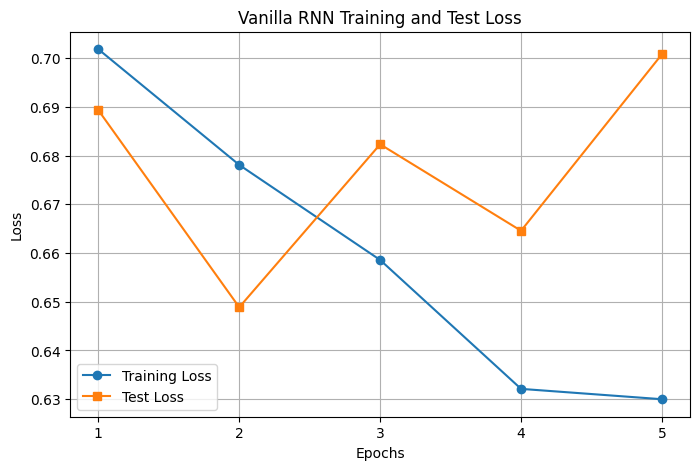

In [4]:
# Runnning model
print(f"Vanilla RNN Parameters: {count_parameters(model_rnn):,}")
print("Running Vanilla RNN Model...")
print()
vanilla_rnn = run_training(model_rnn, train_loader, test_loader, device)

# Plotting Graph
print("Generating Plot...")
epochs = range(1, 6)
train_loss = vanilla_rnn["train_loss"]
test_loss = vanilla_rnn["test_loss"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, test_loss, label='Test Loss', marker='s')
plt.title('Vanilla RNN Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

LSTM Sentiment Classifier: From RNN to LSTM

The Long Short-Term Memory (LSTM) adds gates that let the model decide what to remember and what to forget. In PyTorch, swapping an RNN for an LSTM requires only one line change — but the performance gain is substantial.

The key difference: <span style="font-family: 'JetBrians';"> nn.LSTM </span> returns
(output, (hidden, cell)) instead of (output, hidden). We use only the final hidden state for classification.

## LSTM MODEL Implementation

In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=2, dropout=0.5):
        super().__init__()

        # padding_idx=0 to ignore and prevent learning weights from padding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, n_classes)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        batch_size = x.size(0) # Finds total reviews
        out = output[torch.arange(batch_size), lengths - 1] # Extracts hidden state before padding starts
        return self.fc(self.dropout(out)) # Apply dropout to prevent linear classifier from overfitting

# Initiate and Train
set_seed(42)
model_lstm = LSTMClassifier(
    vocab_size = len(vocab),
    embed_dim  = 128,
    hidden_dim = 256,
    n_classes  = 2,
    n_layers   = 2
)
print(model_lstm)

LSTMClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


### Running LSTM model and Plotting graph comparing Training Loss

LSTM Parameters: 3,482,370
Running LSTM Model...

Epoch 1/5 | Time: 34.13 seconds
Train Loss: 0.6570 | Train Acc: 60.69%
Test Loss:  0.6068 | Test Acc:  68.38%

Epoch 2/5 | Time: 45.06 seconds
Train Loss: 0.6093 | Train Acc: 67.63%
Test Loss:  0.5875 | Test Acc:  71.24%

Epoch 3/5 | Time: 37.20 seconds
Train Loss: 0.5132 | Train Acc: 75.80%
Test Loss:  0.6014 | Test Acc:  76.28%

Epoch 4/5 | Time: 34.23 seconds
Train Loss: 0.4410 | Train Acc: 80.78%
Test Loss:  0.4380 | Test Acc:  81.02%

Epoch 5/5 | Time: 33.93 seconds
Train Loss: 0.3769 | Train Acc: 83.94%
Test Loss:  0.3786 | Test Acc:  85.51%

Average Epoch Time: 36.91 seconds
Generating Plot...


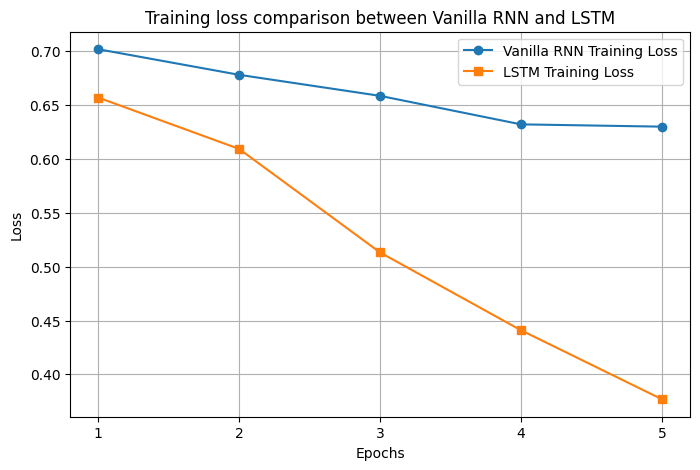

In [6]:
# Runnning model
print(f"LSTM Parameters: {count_parameters(model_lstm):,}")
print("Running LSTM Model...")
print()
lstm = run_training(model_lstm, train_loader, test_loader, device)

# Plotting Graph
print("Generating Plot...")
epochs = range(1, 6)
rnn_train_loss = vanilla_rnn["train_loss"]
lstm_train_loss = lstm["train_loss"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_train_loss, label='Vanilla RNN Training Loss', marker='o', color='tab:blue')
plt.plot(epochs, lstm_train_loss, label='LSTM Training Loss', marker='s', color='tab:orange')

plt.title('Training loss comparison between Vanilla RNN and LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

## Bidirectional LSTM Implementation

A unidirectional LSTM only reads text left-to-right. A Bidirectional LSTM (BRNN) runs two LSTMs in parallel — one forward, one backward — and concatenates their hidden states. This gives every token access to both its past and its future context.

Only two changes from <span style="font-family: 'JetBrians';"> LSTMClassifier:</span>
add <span style="font-family: 'JetBrians';"> bidirectional=True</span>  to <span style="font-family: 'JetBrians';"> nn.LSTM</span>, and double the input size of <span style="font-family: 'JetBrians';"> nn.Linear</span>.

In [7]:
class BRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=2, dropout=0.5):
        super().__init__()

        # padding_idx=0 to ignore and prevent learning weights from padding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        batch_size = x.size(0) # Finds total reviews
        # Extracts forward hidden state before padding starts
        forwards = output[torch.arange(batch_size), lengths - 1, :self.lstm.hidden_size]
        backwards = output[:, 0, self.lstm.hidden_size:] # Extracts backward hidden state from index 0
        out = torch.cat((forwards, backwards), dim=1) # Joins the two states side by side into a tensor
        return self.fc(self.dropout(out)) # Apply dropout to prevent linear classifier from overfitting

# Initiate and Train
set_seed(42)
model_brnn = BRNNClassifier(
    vocab_size = len(vocab),
    embed_dim  = 128,
    hidden_dim = 256,
    n_classes  = 2,
    n_layers   = 2
)
print(model_brnn)

BRNNClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


### Running BRNN model and Plotting graph comparing Training Loss

BRNN Parameters: 4,928,770
Running BRNN Model...

Epoch 1/5 | Time: 73.03 seconds
Train Loss: 0.6413 | Train Acc: 62.21%
Test Loss:  0.6215 | Test Acc:  62.04%

Epoch 2/5 | Time: 72.99 seconds
Train Loss: 0.5497 | Train Acc: 72.39%
Test Loss:  0.5298 | Test Acc:  73.27%

Epoch 3/5 | Time: 72.04 seconds
Train Loss: 0.4675 | Train Acc: 78.18%
Test Loss:  0.4005 | Test Acc:  81.82%

Epoch 4/5 | Time: 77.05 seconds
Train Loss: 0.4007 | Train Acc: 82.40%
Test Loss:  0.3995 | Test Acc:  80.85%

Epoch 5/5 | Time: 85.30 seconds
Train Loss: 0.3500 | Train Acc: 84.87%
Test Loss:  0.3520 | Test Acc:  86.04%

Average Epoch Time: 76.08 seconds
Generating Plot...


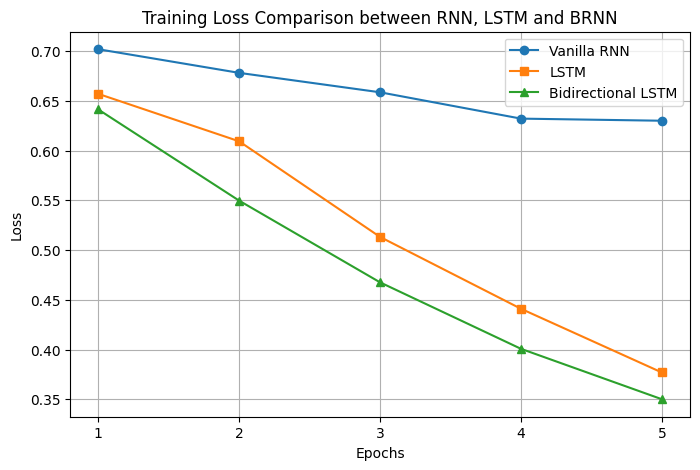

In [8]:
print(f"BRNN Parameters: {count_parameters(model_brnn):,}")
print("Running BRNN Model...")
print()
brnn = run_training(model_brnn, train_loader, test_loader, device)

# Plotting Graph
print("Generating Plot...")
epochs = range(1, 6)
rnn_train_loss = vanilla_rnn["train_loss"]
lstm_train_loss = lstm["train_loss"]
brnn_train_loss = brnn["train_loss"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_train_loss, label='Vanilla RNN', marker='o', color='tab:blue')
plt.plot(epochs, lstm_train_loss, label='LSTM', marker='s', color='tab:orange')
plt.plot(epochs, brnn_train_loss, label='Bidirectional LSTM', marker='^', color='tab:green')

plt.title('Training Loss Comparison between RNN, LSTM and BRNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

## Experiments, Analysis and Report

### HEAD-TO-HEAD SUMMARY TABLE

| Model| TestAccuracy | Parameters | Avg Epoch Time |
| --- | --- | --- | --- |
| Vanilla RNN | 62.71% | 2,659,586 | 5.30 seconds |
| LSTM |  85.51% | 3,482,370 | 36.91 seconds |
| BRNN | 86.04% | 4,928,770 | 76.08 seconds |


**Interpretation :** The Vanilla RNN is the fastest model in terms of time due to its simple architecture and low parameter count, but achieves the lowest accuracy because it suffers from the vanishing gradient problem. The standard LSTM solves this memory loss using internal gates, drastically improving test accuracy at the cost of a slightly longer training time. The Bidirectional LSTM requires the most parameters and the longest training time per epoch since it runs two networks in parallel, but it achieves the highest overall accuracy by analyzing the sequence context from both directions simultaneously.

### LIVE PREDICTION FUNCTION

In [9]:
def predict_sentiment(text, model, vocab, device):
    model.eval() # Switch to evaluation mode

    tokens = tokenize(text)[:MAX_LEN]
    encoded = [vocab.get(t, 1) for t in tokens] # converts word to their integer ID.

    # Adding a fake batch dimension so the shape becomes (1, sequence_length)
    tensor_text = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)
    tensor_length = torch.tensor([len(encoded)], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(tensor_text, tensor_length)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    sentiment = "Positive" if predicted_class.item() == 1 else "Negative"
    conf_score = confidence.item() * 100

    return sentiment, conf_score

### Reviews

In [10]:
reviews = {
    1: "This movie was an absolute masterpiece. The acting was brilliant and the story kept me hooked.", # Obvious Positive
    2: "What a terrible waste of time. The plot made no sense and the characters were incredibly boring.", # Obvious Negative
    3: "It had some okay moments, but overall I felt pretty let down by the slow pacing.", # Ambiguous Negative
    4: "Not exactly what I expected, but the stunning visuals definitely made it worth watching." # Ambiguous Positive
}

### Running Live predictions

In [11]:
print("--- Live Predictions using the BRNN Model ---\n")
for review_id, review_text in reviews.items():
    sentiment, conf = predict_sentiment(review_text, model_brnn, vocab, device)
    print(f"Review {review_id}: '{review_text}'")
    print(f"Prediction: {sentiment} (Confidence: {conf:.2f}%)\n")

--- Live Predictions using the BRNN Model ---

Review 1: 'This movie was an absolute masterpiece. The acting was brilliant and the story kept me hooked.'
Prediction: Positive (Confidence: 99.14%)

Review 2: 'What a terrible waste of time. The plot made no sense and the characters were incredibly boring.'
Prediction: Negative (Confidence: 99.91%)

Review 3: 'It had some okay moments, but overall I felt pretty let down by the slow pacing.'
Prediction: Negative (Confidence: 86.93%)

Review 4: 'Not exactly what I expected, but the stunning visuals definitely made it worth watching.'
Prediction: Positive (Confidence: 90.27%)



### ERROR ANALYSIS

In [12]:
def analyze_errors(model, loader, vocab, device, num_examples=5):
    model.eval() # Switch to evaluation mode

    # Reverse Dictionary to convert integer ID to their words
    idx_to_word = {idx: word for word, idx in vocab.items()}

    mismatches_found = 0

    with torch.no_grad():
        for texts, labels, lengths in loader:
            texts = texts.to(device)
            labels = labels.to(device)
            output = model(texts, lengths)
            _, predicted = torch.max(output, 1)

            mismatch_indices = torch.where(predicted != labels)[0] # Finds missmatched prediction

            for i in mismatch_indices:
                if mismatches_found >= num_examples:
                    return
                text_tensor = texts[i]
                true_label = labels[i].item()
                pred_label = predicted[i].item()

                # Converts Interger IDs to words
                words = []
                for idx in text_tensor:
                    val = idx.item()
                    if val == 0:
                        break

                    words.append(idx_to_word.get(val, "<UNK>"))

                review_text = " ".join(words[:100])

                true_str = "Positive" if true_label == 1 else "Negative"
                pred_str = "Positive" if pred_label == 1 else "Negative"

                print(f"Example {mismatches_found + 1}:")
                print(f"True Label: {true_str} | Predicted: {pred_str}")
                print(f"Review: {review_text}...\n")

                mismatches_found += 1

In [13]:
print("!!! Error Analysis using BRNN Model !!!\n")
analyze_errors(model_brnn, test_loader, vocab, device, num_examples=5)

!!! Error Analysis using BRNN Model !!!

Example 1:
True Label: Negative | Predicted: Positive
Review: first off let me say if you haven't enjoyed a van damme movie since <unk> you probably will not like this movie most of these movies may not have the best plots or best actors but i enjoy these kinds of movies for what they are this movie is much better than any of the movies the other action guys segal and dolph have thought about putting out the past few years van damme is good in the movie the movie is only worth watching to van damme fans it is not as good as wake of death which i...

Example 2:
True Label: Negative | Predicted: Positive
Review: isaac <unk> has made some of the best western martial arts action movies ever produced in particular us seals cold harvest special forces and undisputed are all action classics you can tell isaac has a real passion for the genre and his films are always eventful creative and sharp affairs with some of the best fight sequences an action fan

### Observations

By going over the mismatched examples manually, it is clear the model struggles on these types of review patterns.

**(1) Bait and Switch reviews:** These reviews contain a long positive introduction to give a negative review. In example 2, the reviewer spends 80 words praising the director's past works using strong positive tokens like "best", "classics", "passion", and "talented". The actual negative critique does not appear until the very end. Because the model calculates the mathematical weight of all the tokens in sequence, the sheer number of positive words drowns out the late bait and switch to a negative verdict. Example 4 follows the exact same pattern, calling the premise "intriguing" then switching over to "muddled" and "frustrated" by the end.

**(2) Misleading Comparative reviews:** The model also struggles with reviews that use positive words in a negative context. In example 1, the reviewer uses positive words like "good", "enjoy", and "better" to say the movie is slightly better than another terrible action movie, but still overall a bad experience. In example 5, the reviewer uses words like "great" and "good" to praise entirely different movies and actors instead of the actual movie they are reviewing. The model scans these words and sees a high concentration of positive tokens. It then moves the scale over to a positive review, completely missing the comparative context.

In [14]:
torch.cuda.empty_cache()